In [16]:
import sqlite3
import matplotlib.pyplot as plt

# Connecting to the database

In [3]:
conn=sqlite3.connect("sales_data.db")
cursor=conn.cursor()

# Creating Sales table

In [4]:
cursor.execute(""" 
CREATE TABLE IF NOT EXISTS SALES(
id INTEGER PRIMARY KEY AUTOINCREMENT,
product TEXT,
quantity INTEGER,
price REAL)
""")

# Inserting values into sales table

In [5]:
sales_data=[
    ("Apples", 10, 2.5),
    ("Bananas", 5, 1.0),
    ("Apples", 7, 2.5),
    ("Oranges", 8, 1.8),
    ("Bananas", 12, 1.0),
]

In [6]:
cursor.executemany("INSERT INTO SALES (product,quantity,price) VALUES (?,?,?)",sales_data)
conn.commit()

# Run the SQL queries and load into pandas

In [8]:
import pandas as pd

In [9]:
query= """
SELECT 
  product,
  sum(quantity) as total_quantity,
  sum(quantity*price) as revenue
FROM SALES
GROUP BY product
"""

df=pd.read_sql_query(query,conn)

In [10]:
df

,product,total_quantity,revenue
0,Apples,17,42.5
1,Bananas,17,17.0
2,Oranges,8,14.4


In [11]:
query1="""
SELECT 
   DISTINCT product
FROM SALES
"""

df1=pd.read_sql_query(query1,conn)

In [12]:
df1

,product
0,Apples
1,Bananas
2,Oranges


In [14]:
query2="""
SELECT * FROM SALES
"""

df2=pd.read_sql_query(query2,conn)

In [15]:
df2

,id,product,quantity,price
0,1,Apples,10,2.5
1,2,Bananas,5,1.0
2,3,Apples,7,2.5
3,4,Oranges,8,1.8
4,5,Bananas,12,1.0


# Barchart

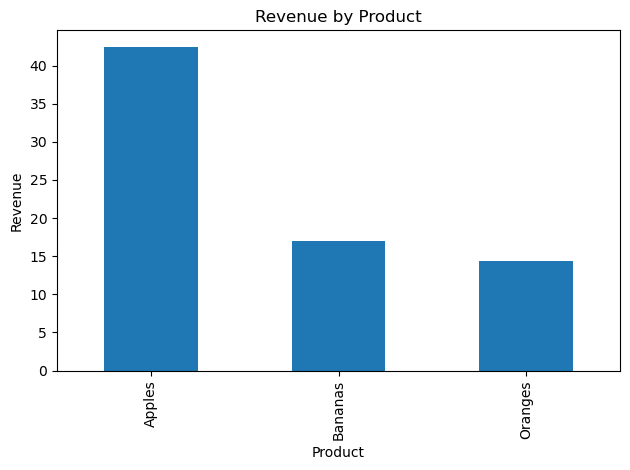

In [17]:
df.plot(kind="bar",x="product",y="revenue",legend=False)
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()